In [1]:
import mne
from pathlib import Path

# 1. Configuration
bids_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
sub_number = "02"
task = "loc"

# Define Paths
deriv_root = bids_root / f"sub-{sub_number}" / "eeg"
fname_in = deriv_root / f"sub-{sub_number}_task-{task}_downsamp-2_desc-filteredICAdReref_eeg.fif"
fname_out = deriv_root / f"sub-{sub_number}_task-{task}_epoched_eeg.fif"

print(f"Processing Subject: {sub_number}")
print(f"Input file: {fname_in}")
print(f"Output file: {fname_out}")

Processing Subject: 02
Input file: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_downsamp-2_desc-filteredICAdReref_eeg.fif
Output file: C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_epoched_eeg.fif


In [2]:
# Find and read the raw file
raw = mne.io.read_raw_fif(fname_in, preload=True)
events, event_dict = mne.events_from_annotations(raw)

Opening raw data file C:\Users\noahm\projects\loc_analysis\data\derivatives\sub-02\eeg\sub-02_task-loc_downsamp-2_desc-filteredICAdReref_eeg.fif...
    Range : 0 ... 1294719 =      0.000 ...  2589.438 secs
Ready.
Reading 0 ... 1294719  =      0.000 ...  2589.438 secs...
Used Annotations descriptions: [np.str_('dist_end'), np.str_('dist_start'), np.str_('enc_act1'), np.str_('enc_act2'), np.str_('enc_act3'), np.str_('enc_cue'), np.str_('enc_end'), np.str_('enc_fixation'), np.str_('enc_q_color'), np.str_('enc_q_schema'), np.str_('enc_resp_left'), np.str_('enc_resp_right'), np.str_('enc_start'), np.str_('prac_end'), np.str_('prac_start'), np.str_('psychopy_enc_starts'), np.str_('psychopy_ret_starts'), np.str_('ret_cue_new'), np.str_('ret_cue_old_sc_pc'), np.str_('ret_cue_old_sc_pi'), np.str_('ret_cue_old_si_pc'), np.str_('ret_cue_old_si_pi'), np.str_('ret_end'), np.str_('ret_fixation'), np.str_('ret_q1_new'), np.str_('ret_q1_old_sc_pc'), np.str_('ret_q1_old_sc_pi'), np.str_('ret_q1_old_si_

## Epoching

In [ ]:
# If we want to select epochs based on a condition, we can use the `selection` parameter
# Which is a dictionary with the condition as key and the list of values as value
reject_criteria = dict(
    eeg=150e-6,  # 150 µV
) 

# Create epochs from the raw data
epochs = mne.Epochs(
    raw, # raw data
    events, # event data
    event_id=event_dict, # dictionary with event names and their corresponding IDs
    tmin=-0.2,
    tmax=2, # 200ms before and 2000ms after the event
    reject=reject_criteria, # reject epochs based on the criteria - amplitude
    baseline=(None, 0), # apply using pre-stim baseline period
    preload=True, # put into memory
)

# Without Ivan's rejection criteria, we get n = 14 (of 16) trials per condition cell for encoding_target.
# With this criterion, we only get n = 11.5 trials.

# In the retrieval condition, without rejection, we get n = 10.25 (of 16) trials per condition cell for ret_cue.
# With rejection, we get 3+3+1+0 = 7, on average n = 1.75 trials per condition.

Not setting metadata
1122 matching events found


Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1122 events and 1101 original time points ...
    Rejecting  epoch based on EEG : ['FC5', 'C5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch based on EEG : ['FC5', 'F5', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'F5', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'F5', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'T7', 'FT7', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'FT7', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'FC3']
    Rejecting  epoch based on EEG : ['FC5', 'FC3', 'C5']
    Rejecting  epoch based on EEG : ['FC5', 'FC3

In [4]:
# Select only the conditions we care about
conds_we_care_about = ["tgt_sc_pc", "tgt_sc_pi", "tgt_si_pc", "tgt_si_pi"]
# Equalize the number of epochs in each condition
epochs.equalize_event_counts(conds_we_care_about, method='random', random_state=42)  # this operates in-place

Dropped 4 epochs: 89, 167, 183, 213


(<Epochs | 931 events (all good), -0.2 – 2 s (baseline -0.2 – 0 s), ~508.4 MiB, data loaded,
  np.str_('dist_end'): 0
  np.str_('dist_start'): 0
  np.str_('enc_act1'): 55
  np.str_('enc_act2'): 57
  np.str_('enc_act3'): 58
  np.str_('enc_cue'): 57
  np.str_('enc_end'): 0
  np.str_('enc_fixation'): 58
  np.str_('enc_q_color'): 31
  np.str_('enc_q_schema'): 29
  and 40 more events ...>,
 array([167, 183,  89, 213]))

### Rereference to average

Not setting metadata
14 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
14 matching events found
No baseline correction applied
0 projection items activated


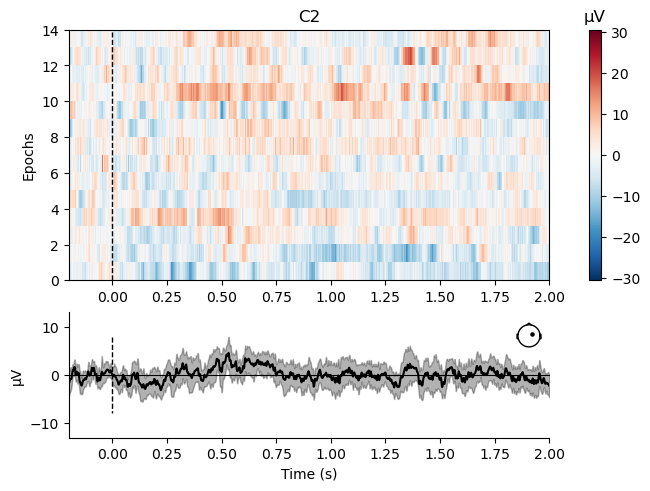

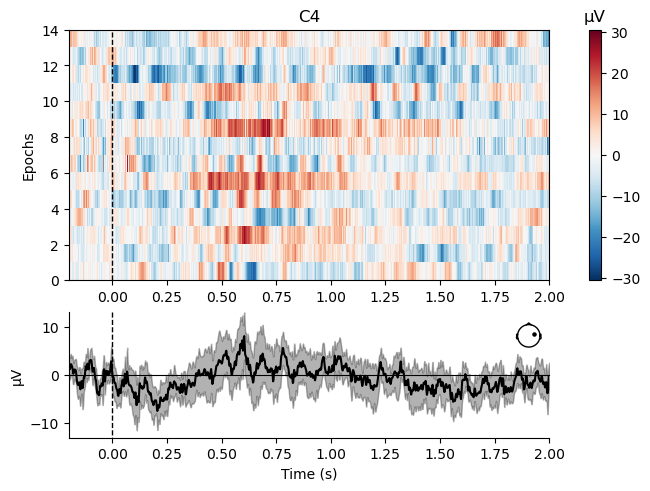

[<Figure size 640x480 with 4 Axes>, <Figure size 640x480 with 4 Axes>]

In [5]:
# Get a contrast between SCPC and SIPC  conditions
sc_pc_epochs = epochs["tgt_sc_pc"] # Selecting done by the event description (key in the event_dict)
si_pc_epochs = epochs["tgt_si_pc"]

# Plot the data from the epochs - it is a 3D array
sc_pc_epochs.plot_image(picks=["C2", "C4"])

# ERPs

In [20]:
# Let's average the epochs for each condition
tgt_sc_pc = epochs["tgt_sc_pc"].average()
tgt_sc_pi = epochs["tgt_sc_pi"].average()
tgt_si_pc = epochs["tgt_si_pc"].average()
tgt_si_pi = epochs["tgt_si_pi"].average()

No projector specified for this dataset. Please consider the method self.add_proj.


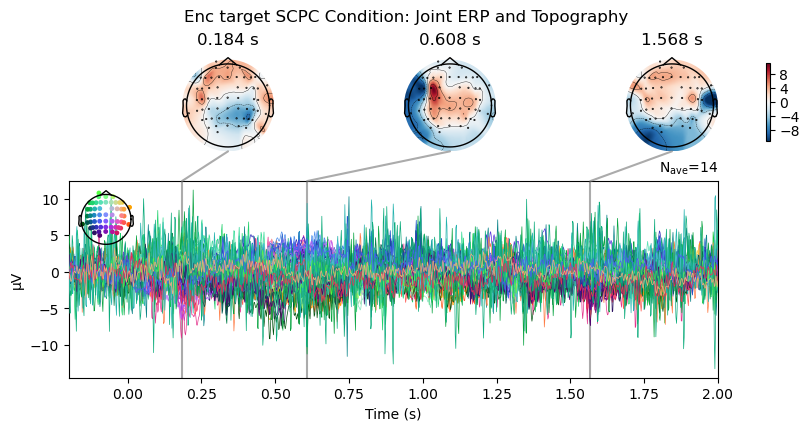

No projector specified for this dataset. Please consider the method self.add_proj.


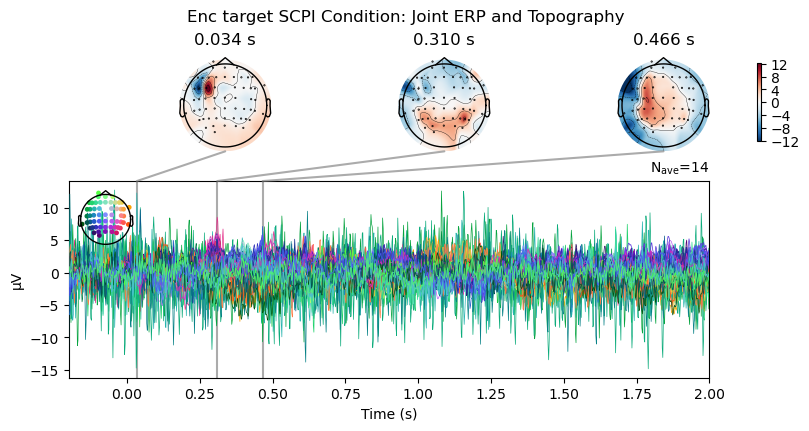

No projector specified for this dataset. Please consider the method self.add_proj.


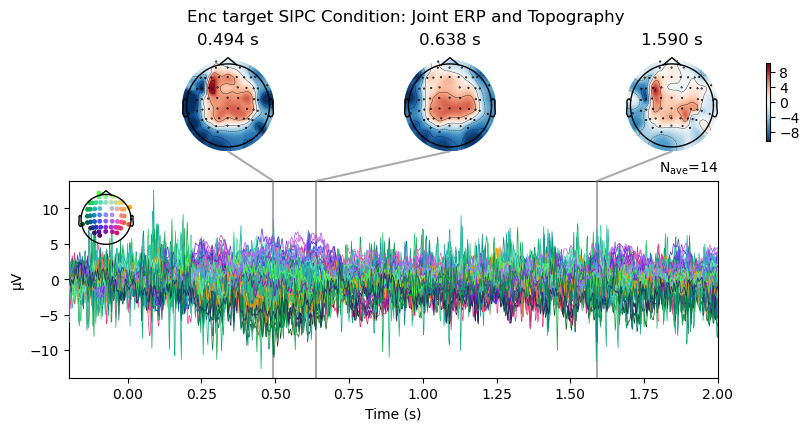

No projector specified for this dataset. Please consider the method self.add_proj.


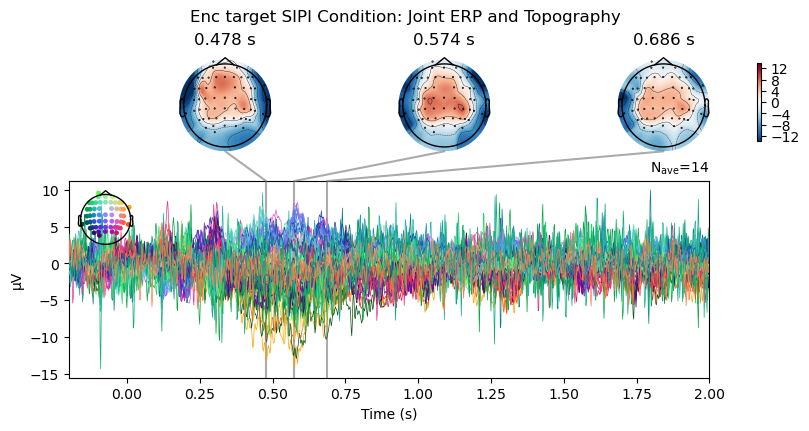

In [11]:
fig1 = tgt_sc_pc.plot_joint(title="Enc target SCPC Condition: Joint ERP and Topography")
fig2 = tgt_sc_pi.plot_joint(title="Enc target SCPI Condition: Joint ERP and Topography")
fig3 = tgt_si_pc.plot_joint(title="Enc target SIPC Condition: Joint ERP and Topography")
fig3 = tgt_si_pi.plot_joint(title="Enc target SIPI Condition: Joint ERP and Topography")

I also wanna have a look at an event during the retrieval phase

In [16]:
# Select only the conditions we care about
conds_we_care_about = ["ret_cue_old_sc_pc", "ret_cue_old_sc_pi", "ret_cue_old_si_pc", "ret_cue_old_si_pi"]
# Equalize the number of epochs in each condition
epochs.equalize_event_counts(conds_we_care_about, method='random', random_state=42)  # this operates in-place

Dropped 7 epochs: 347, 352, 373, 407, 413, 422, 434


(<Epochs | 441 events (all good), -0.2 – 2 s (baseline -0.2 – 0 s), ~240.9 MiB, data loaded,
  np.str_('dist_end'): 0
  np.str_('dist_start'): 0
  np.str_('enc_act1'): 41
  np.str_('enc_act2'): 40
  np.str_('enc_act3'): 42
  np.str_('enc_cue'): 43
  np.str_('enc_end'): 0
  np.str_('enc_fixation'): 45
  np.str_('enc_q_color'): 24
  np.str_('enc_q_schema'): 22
  and 40 more events ...>,
 array([352, 373, 434, 407, 413, 422, 347]))

In [23]:
# Let's average the epochs for each condition
#ret_cue_sc_pc = epochs["ret_cue_old_sc_pc"].average()
ret_cue_sc_pi = epochs["ret_cue_old_sc_pi"].average()
ret_cue_si_pc = epochs["ret_cue_old_si_pc"].average()
ret_cue_si_pi = epochs["ret_cue_old_si_pi"].average()

No projector specified for this dataset. Please consider the method self.add_proj.


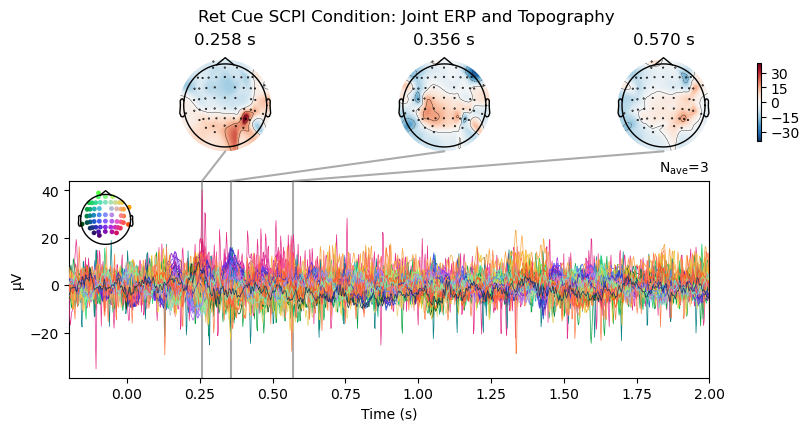

No projector specified for this dataset. Please consider the method self.add_proj.


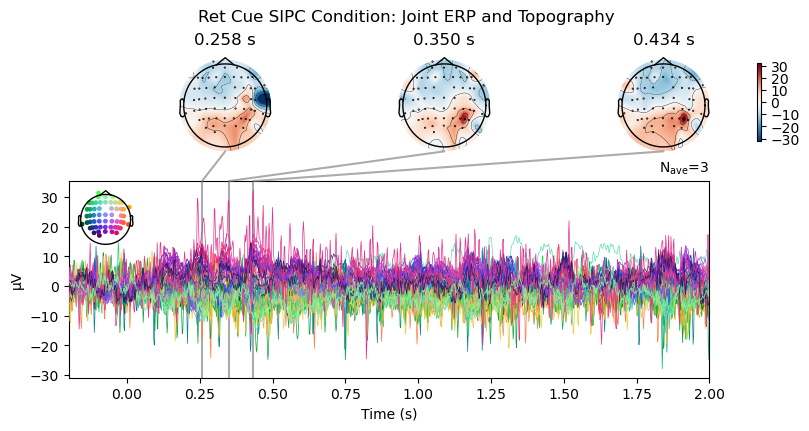

No projector specified for this dataset. Please consider the method self.add_proj.


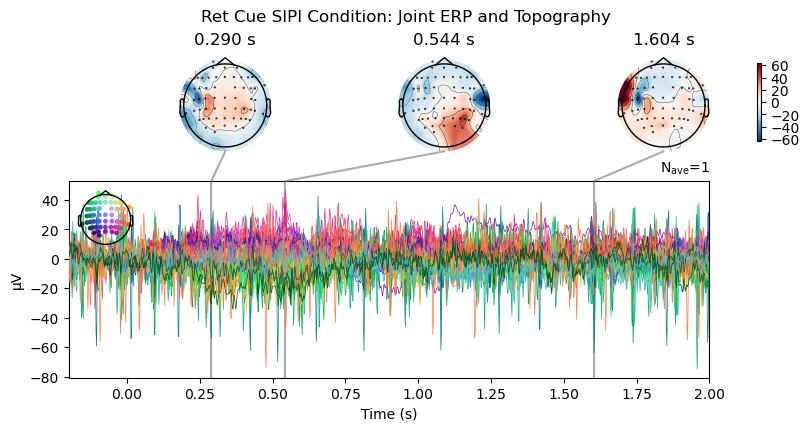

In [24]:
# fig5 = ret_cue_sc_pc.plot_joint(title="Ret Cue SCPC Condition: Joint ERP and Topography")
fig6 = ret_cue_sc_pi.plot_joint(title="Ret Cue SCPI Condition: Joint ERP and Topography")
fig7 = ret_cue_si_pc.plot_joint(title="Ret Cue SIPC Condition: Joint ERP and Topography")
fig8 = ret_cue_si_pi.plot_joint(title="Ret Cue SIPI Condition: Joint ERP and Topography")

Comparing conditions (later)

More than 6 channels, truncating title ...
combining channels using "mean"
combining channels using "mean"


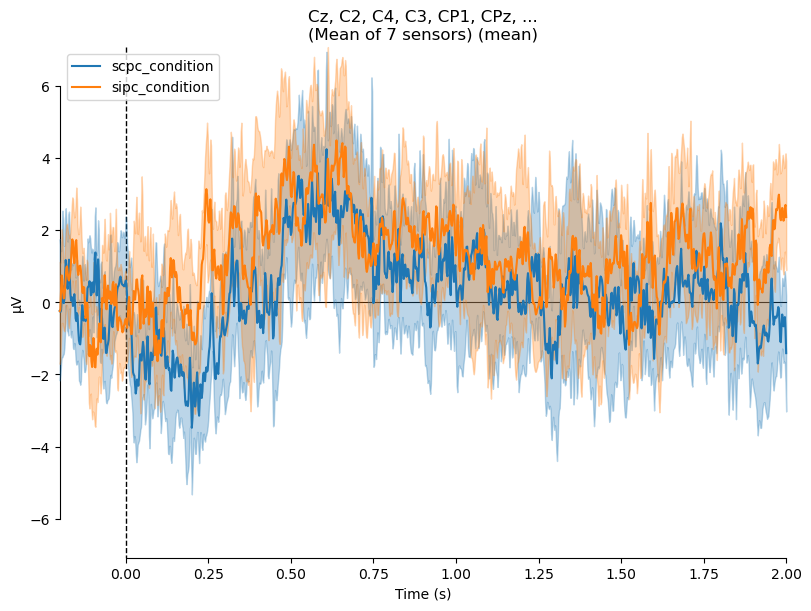

[<Figure size 800x600 with 1 Axes>]

In [ ]:
picks = ['Cz', 'C2', 'C4', 'C3', 'CP1', 'CPz', 'CP2']
evokeds = dict(
    scpc_condition=list(epochs["tgt_sc_pc"].iter_evoked()),
    sipc_condition=list(epochs["tgt_si_pc"].iter_evoked()),
)
mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)

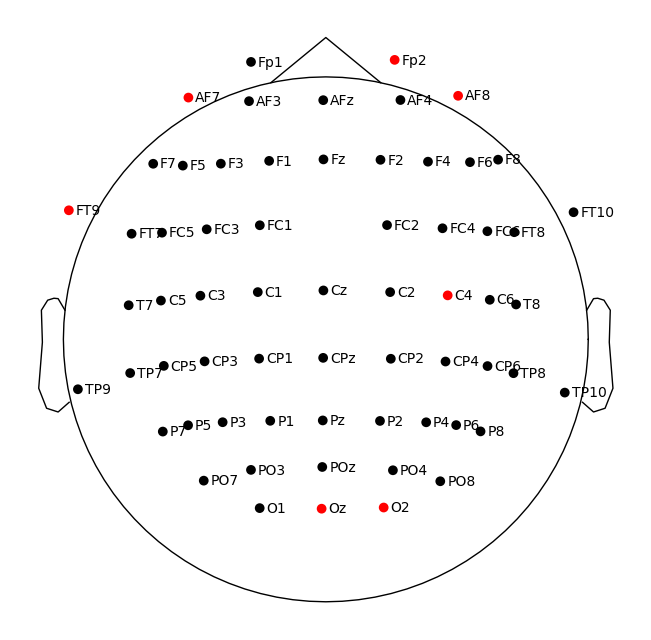

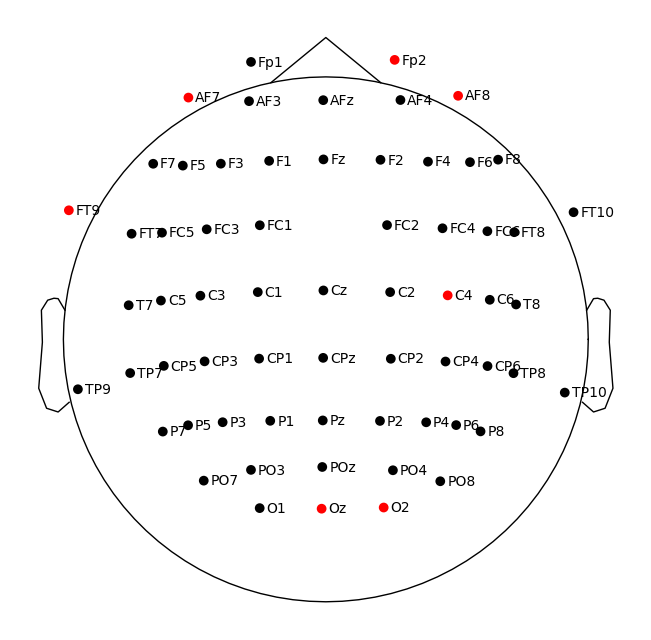

In [11]:
raw.plot_sensors(show_names=True)

No projector specified for this dataset. Please consider the method self.add_proj.


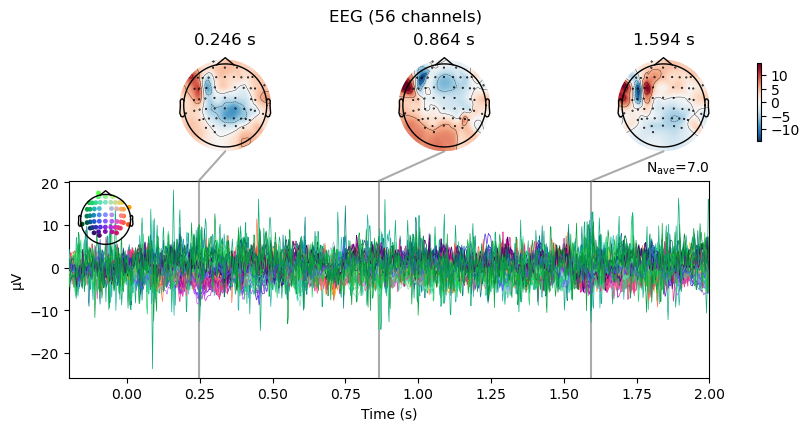

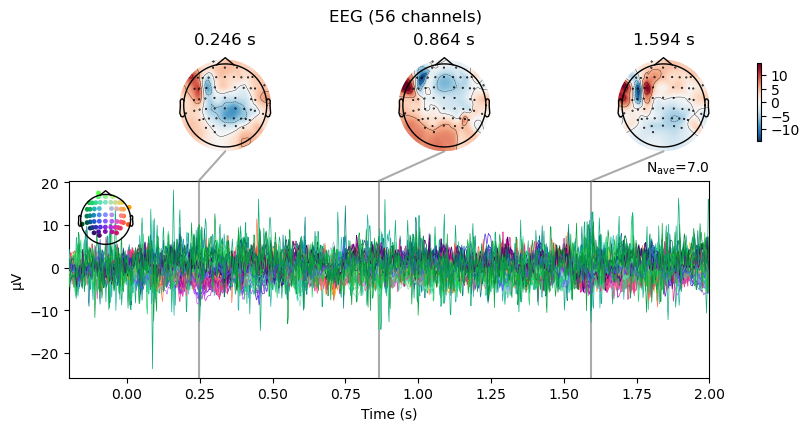

In [9]:
# Plot the subtracted difference: 
scpc_minus_sipc = mne.combine_evoked([tgt_sc_pc, tgt_si_pc], weights=[1, -1])
scpc_minus_sipc.plot_joint()

In [ ]:
reconst_raw.save("reconst_raw.fif")

new_reconst_raw = mne.io.read_raw_fif("reconst_raw.fif")

In [44]:
epochs.save("epochs-epo.fif")

#new_epochs = mne.read_epochs("epochs-epo.fif")